# Bayesian Inference III
# Bayesian Regression Extended

This article is part of a series...

- <a href="">Bayesian Inference I - Bayesian Inference</a>
- <a href="">Bayesian Inference II - Bayesian Linear Regression</a>
- <a href="">Bayesian Inference III - Extending Bayesian Regression</a>
- <a href="">Bayesian Inference IV - Discrete Bayesian Networks</a>
- <a href="">Bayesian Inference V - Continuous and Hybrid Bayesian Networks</a>
- <a href="">Bayesian Inference VI - Generalized Bayesian Networks (under construction)</a>

## Outline

<u>The Generalized Linear Model (GLM)</u>

<u>Poisson Regression</u>

<ul>
<li>Poisson Regression</li>
<ul>
    <li>Setting Priors</li>
    <li>Prior Predictive Checks</li>
</ul>
</br>
<li>Zero-Inflated Poisson Regression</li>
<ul>
    <li>Setting Priors</li>
    <li>Prior Predictive Checks</li>
    <li>Fitting Data</li>
    <li>Posterior Predictive Inference</li>
</ul>
</br>

</ul>

<u>Negative Binomial Regression</u>

<ul>
<li>Negative Binomial Regression</li>
<ul>
    <li>Setting Priors</li>
    <li>Prior Predictive Checks</li>
</ul>
</br>

<li>Zero-Inflated Negative Binomial Regression</li>
<ul>
    <li>Setting Priors</li>
    <li>Prior Predictive Checks</li>
    <li>Fitting Data</li>
    <li>Posterior Predictive Inference</li>
</ul>
</br>

</ul>

<u>Gamma (and Exponential) Regression</u>

<ul>
<li>Exponential Regression</li>
<ul>
    <li>Setting Priors</li>
    <li>Prior Predictive Checks</li>
</ul>
</br>
<li>Gamma Regression</li>
<ul>
    <li>Setting Priors</li>
    <li>Prior Predictive Checks</li>
    <li>Fitting Data</li>
    <li>Posterior Predictive Inference</li>
</ul>
</ul>

In [1]:
# re: having to set a strong prior to regularize...
# what to consider if the long-run data doesn't fit?
# - evaluate empirically, cross-val...

## The Generalized Linear Model

The GLM is a generalization of the linear model that allows us to use different distributions for the likelihood. It is defined as $Y \sim \phi(f(\mu), \theta)$, where $\phi$ is an arbitrary distribution, such as the Poisson, Negative Binomial, Gamma, or Student's t. $\theta$ represents the auxiliary parameters of the distribution, such as $\sigma$ for the Normal.

$f$ is called the inverse link function. When $\phi$ is Normal, $f$ is the identity function, whereas for distributions like the Gamma and Negative Binomial, $f$ is usually the exponential function. The output of the Normal linear model will generally fall on the real line, and $f$ facilitates any required transformations, such as to ensure the output is strictly positive, or integer-valued.

## Poisson Regression

As mentioned earlier, the Normal model outputs numbers on the real line, including negative numbers and non-integers. For modeling discrete counts of events that occur in a fixed interval of time or space, assuming a Poisson distribution may be more reasonable. It is also handy if the data is right-skewed. We write:

- $Y_i | \lambda_i \sim Pois(\lambda_i)$
- $E(Y_i | \lambda_i) = \lambda_i$

As in Normal regression, we assume that the average result is a linear combination of our predictors. It is common to use a log link function.

- $Y_i | \alpha, \beta_1, \ldots, \beta_p \sim Pois(\lambda_i)$
- $log(\lambda_i) = \alpha + \beta_1 X_1 + \ldots + \beta_p X_p$
- $\lambda_i = exp(\alpha + \beta_1 X_1 + \ldots + \beta_p X_p)$

#### Implementation

The word poisson is french for fish, so how appropriate it is that there is a fishing-related dataset which provdies a natural example for modeling low-valued count data. It tracks the number of fish caught by each group of visitors to a natural partk which also hosts a campground. The features include:
- <code>livebait</code>: whether the visitor brought live bait
- <code>camper</code>: whether the visitor was a camper
- <code>persons</code>: number of visitors in the group
- <code>child</code>: number of children in the group
- <code>count</code>: number of fish caught (I'll rename it to <code>numfish</code>)

In [2]:
# !pip install bambi

In [3]:
import pandas as  pd
import bambi as bmb
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
data = pd.read_csv("https://stats.idre.ucla.edu/stat/data/fish.csv")
cols = ["count", "livebait", "camper", "persons", "child"]
data = data[cols]
data = data.rename(columns={"count": "numfish"})

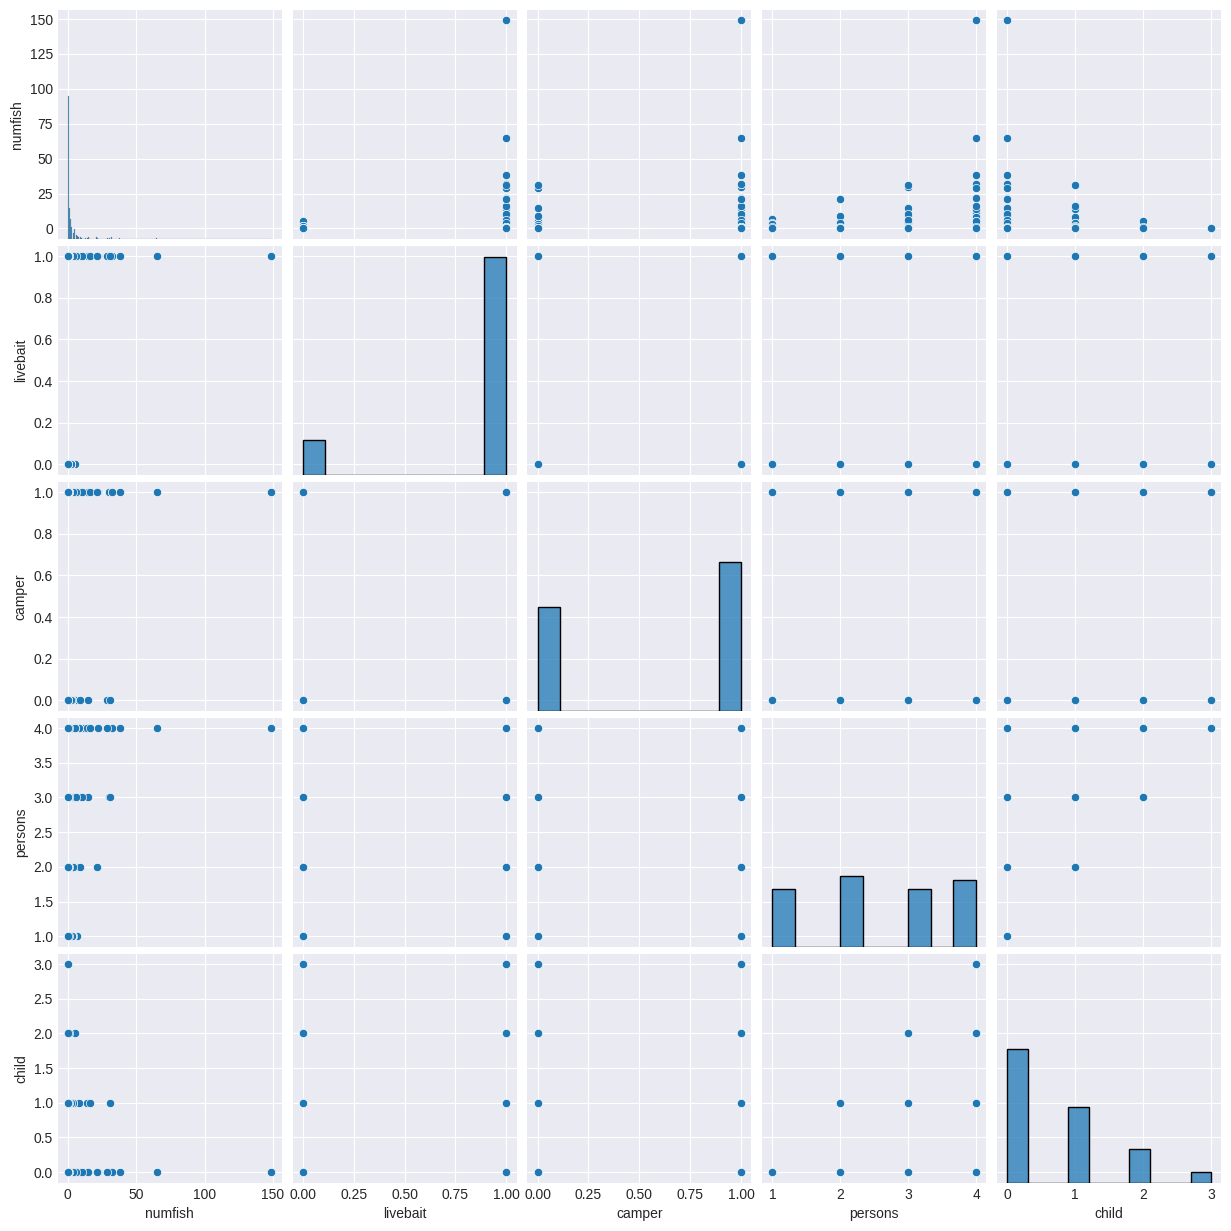

In [5]:
sns.pairplot(data);

In [6]:
data["child"] = data["child"].astype(int)
data["livebait"] = pd.Categorical(data["livebait"])
data["camper"] = pd.Categorical(data["camper"])

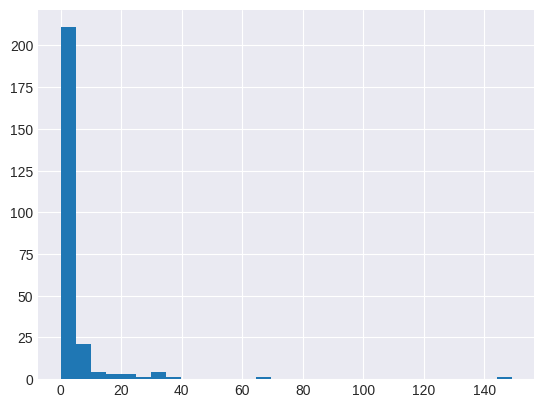

In [7]:
plt.hist(data['numfish'], bins=30);

(array([236.,   7.,   5.,   0.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([  0. ,  14.9,  29.8,  44.7,  59.6,  74.5,  89.4, 104.3, 119.2,
        134.1, 149. ]),
 <BarContainer object of 10 artists>)

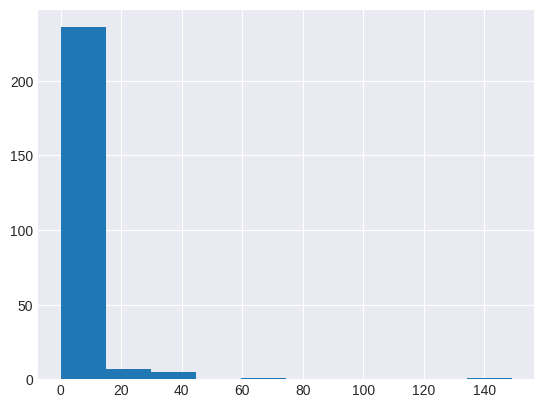

In [8]:
plt.hist(data['numfish'])

In [9]:
data.describe()

,numfish,persons,child
count,250.000000,250.00000,250.000000
mean,3.296000,2.52800,0.684000
std,11.635028,1.11273,0.850315
min,0.000000,1.00000,0.000000
25%,0.000000,2.00000,0.000000
50%,0.000000,2.00000,0.000000
75%,2.000000,4.00000,1.000000
max,149.000000,4.00000,3.000000


To set priors, we could do something like the following, and uncomment the <code>priors=priors</code> line of the model fitting below. I have no strong beliefs or prior/expert knowledge of the subject, so for the sake of demonstration, I have provided this example of how to set the priors, but will let the data speak for itself.

In [10]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1),
    "persons": bmb.Prior("Poisson", mu=2.5),
    "child": bmb.Prior("Poisson", mu=0.7),
    "livebait": bmb.Prior("Bernoulli", p=0.85),
    "camper": bmb.Prior("Bernoulli", p=0.6)
}

In [11]:
model_poisson = bmb.Model(
    "numfish ~ livebait + camper + persons + child",
    data,
    family="poisson",
    priors=priors
)

idata_poisson = model_poisson.fit(
    draws=1000,
    target_accept=0.95,
    random_seed=1234,
    chains=4,
    idata_kwargs={"log_likelihood": True}
)

Output()

Output()

Output()

Output()

/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


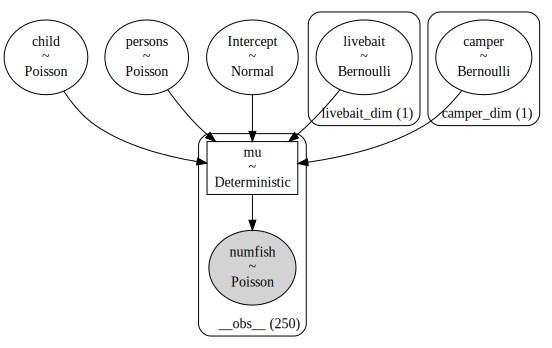

In [12]:
model_poisson.graph()

In [13]:
az.summary(idata_poisson)

/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.338,1.854,-7.241,-3.428,0.923,0.707,6.0,202.0,1.73
camper[1],1.000,0.000,1.000,1.000,0.000,0.000,4000.0,4000.0,NaN
child,0.000,0.000,0.000,0.000,0.000,0.000,4000.0,4000.0,NaN
livebait[1],1.000,0.000,1.000,1.000,0.000,0.000,4000.0,4000.0,NaN
persons,1.500,0.500,1.000,2.000,0.249,0.191,4.0,4.0,12586031.58


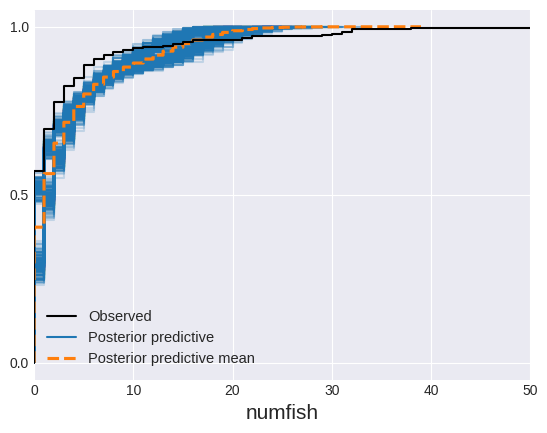

In [14]:
model_poisson.predict(idata_poisson, kind="response")
ax = az.plot_ppc(idata_poisson, num_pp_samples=500, kind="cumulative")
ax.set_xlim(0, 50);

I used <code>kind="cumulative"</code> rather than <code>kind="kde"</code> because the observed data seems to display improperly for this data in <code>kde</code> mode. The model is not of great fit, as you can tell by the observed data residing mostly to the left of the posterior predictive draws, whereas ideally the data would centered, with an equal amount of noise represented on each side.

We can use <code>idata.posterior.to_dataframe()</code> to convert the results provided in an Arviz InferenceData object to a Pandas dataframe.

In [15]:
posterior_df = idata_poisson.posterior.to_dataframe()
posterior_df.head()

Intercept  camper  child  \
chain draw camper_dim livebait_dim __obs__                             
0     0    1          1            0        -7.190826       1      0   
                                   1        -7.190826       1      0   
                                   2        -7.190826       1      0   
                                   3        -7.190826       1      0   
                                   4        -7.190826       1      0   

                                            livebait  persons        mu  
chain draw camper_dim livebait_dim __obs__                               
0     0    1          1            0               1        2  0.005567  
                                   1               1        2  0.041138  
                                   2               1        2  0.015134  
                                   3               1        2  0.303970  
                                   4               1        2  0.015134

Summarizing the data, we can see that the normally distributed parameter of the Poisson 'numfish' variable has a variance much larger than the mean. This could be a reason for poor fit from the Poisson distribution.

In [16]:
posterior_df['mu'].describe()

,mu
count,1000000.000000
mean,3.294875
std,4.704692
min,0.004897
25%,0.289437
50%,1.551252
75%,4.546153
max,19.010752


## Zero-Inflated Poisson Regression

Recall from the histogram above that we have many zeros in the data. This is a fairly common issue to encounter. We want to model count data, but there are more zeros than would allow a Poisson distribution to fit it nicely. Modeling the count of zeros separately from the rest of the distribution is awkward, because then we need a solution to account for the lack of zeros in the remaining data. A more elegant solution is to introduce an extra parameter which allows the distribution to account for an arbitrary level of zeros, and this is the goal of zero-inflated Poisson (ZIP) regression.

ZIP regression introduces another parameter $\psi$ that modulates the PMF. The PMF of the zero-inflated Poisson distribution is:

$P(X=k)  =
\begin{cases}
  \psi + (1-\psi) ~exp(\lambda), ~~~~~~~~~\text{if} ~k=0  \\
  (1-\psi) ~exp(-\lambda) \lambda^k/k!, ~~~~\text{if} ~k \in \{1,2,\ldots\}
\end{cases}$

when $\psi=0$, the zero-inflated Poisson reduces to the Poisson distribution.

The mean and variance are:
- $E(X) = \lambda(1 - \psi)$
- $Var(X) = \lambda(1 - \psi)(1 + \lambda \psi)$

Again, to set priors, we could do something like the following, and uncomment the <code>priors=priors</code> line of the model fitting below. I have no strong beliefs or prior/expert knowledge of the subject, and could choose data-based or uninformative priors, but for the sake of demonstration, will simply provide this placeholder, and let it assume normal distributions for variables outside of the target variable, and a value for psi that is fit from the data (and beta-distributed).

In [17]:
# priors = {
#     "Intercept": bmb.Prior("Normal", mu=-2.6, sigma=0.3),
#     "persons": bmb.Prior("DiscreteUniform", lower=1, upper=4),
#     "child": bmb.Prior("Poisson", mu=0.8),
#     "livebait": bmb.Prior("Bernoulli", p=0.85),
#     "camper": bmb.Prior("Bernoulli", p=0.6)
# }

In [18]:
model_zip = bmb.Model(
    "numfish ~ livebait + camper + persons + child",
    data,
    family="zero_inflated_poisson" #,
    # priors=priors
)

idata_zip = model_zip.fit(
    draws=1000,
    target_accept=0.95,
    random_seed=1234,
    chains=4,
    idata_kwargs={"log_likelihood": True}
)

Output()

Output()

Output()

Output()

We can view a summary of parameter values as follows:

In [19]:
az.summary(idata_zip)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.557,0.293,-3.098,-2.005,0.005,0.004,3412.0,2672.0,1.0
camper[1],0.676,0.095,0.490,0.846,0.002,0.001,3820.0,2700.0,1.0
child,-1.394,0.092,-1.569,-1.223,0.002,0.001,3132.0,2850.0,1.0
livebait[1],1.728,0.247,1.256,2.203,0.004,0.003,4305.0,2544.0,1.0
persons,0.875,0.045,0.795,0.964,0.001,0.001,3274.0,2518.0,1.0
psi,0.616,0.046,0.531,0.702,0.001,0.001,3332.0,2881.0,1.0


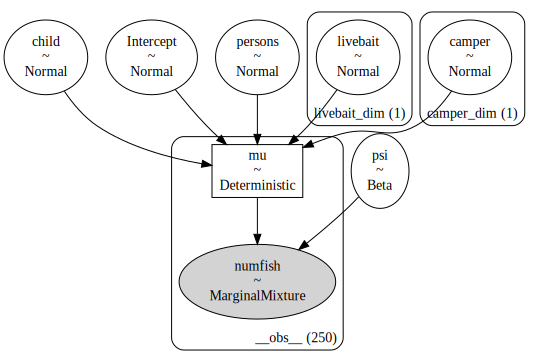

In [20]:
model_zip.graph()

A trace plot will confirm that the sampling converged...

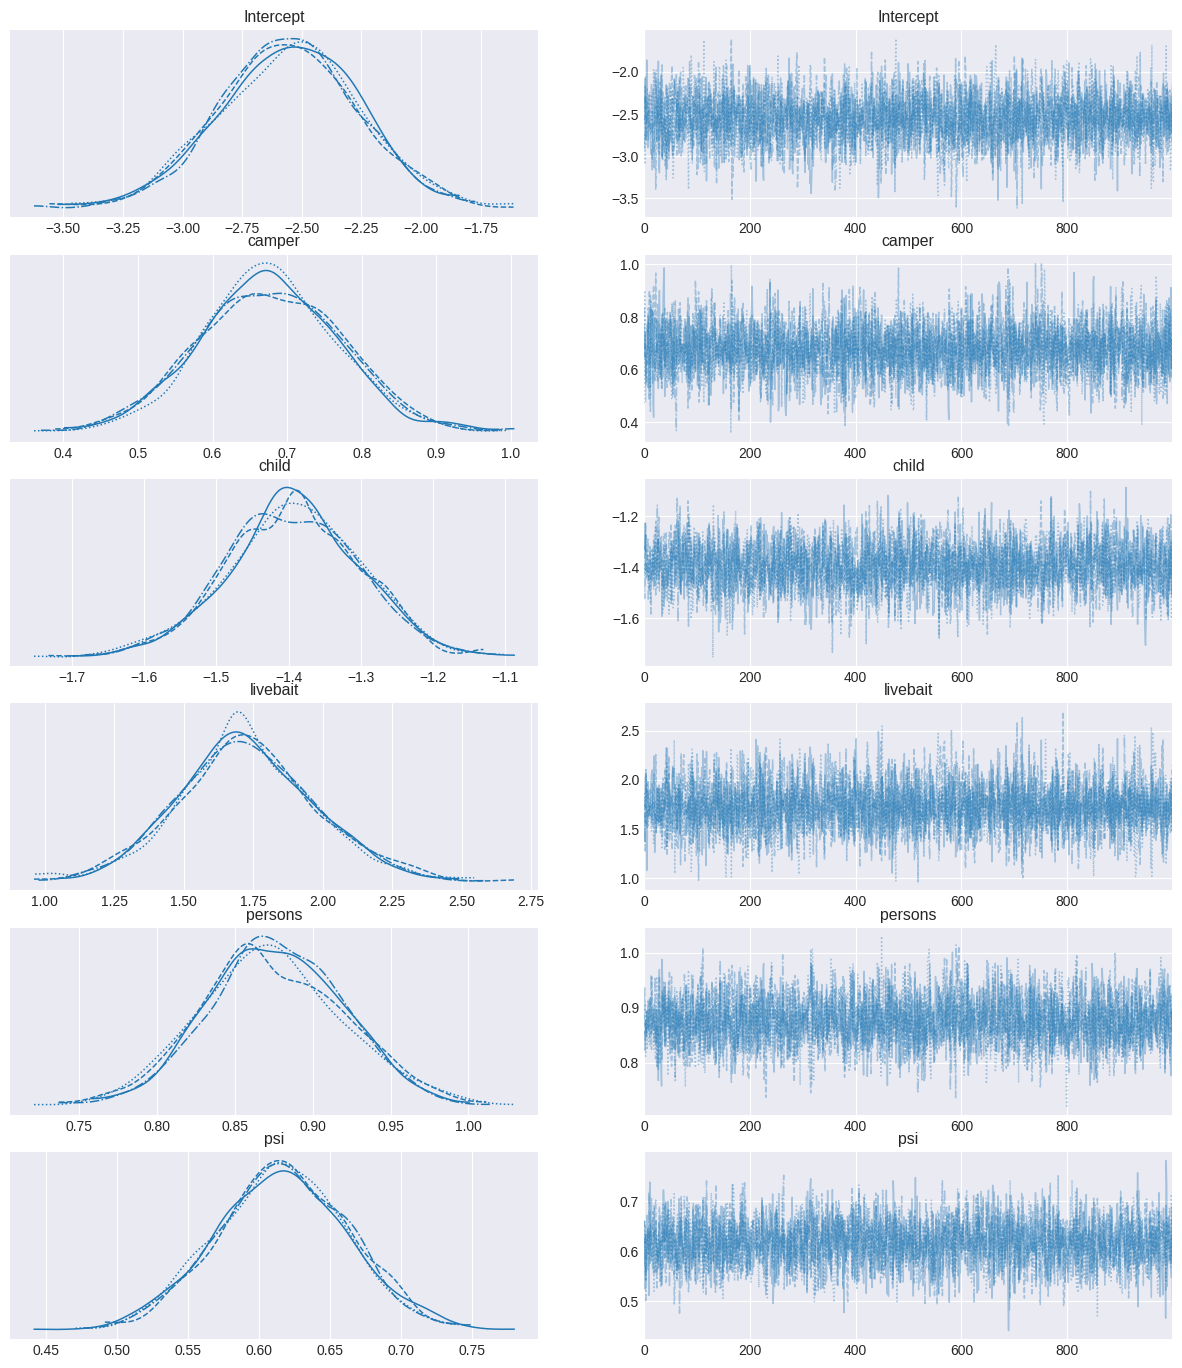

In [21]:
az.plot_trace(idata_zip, figsize=(15,17));

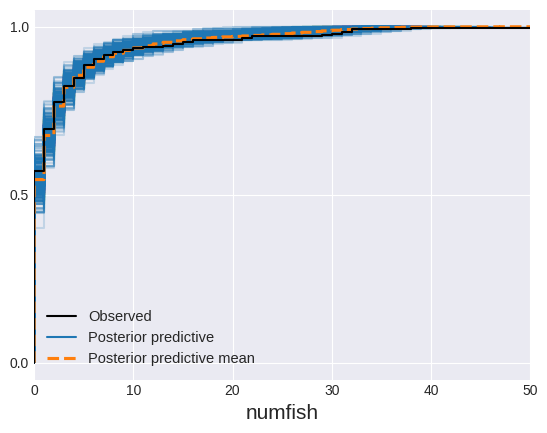

In [22]:
model_zip.predict(idata_zip, kind="response")
ax = az.plot_ppc(idata_zip, num_pp_samples=500, kind="cumulative")
ax.set_xlim(0, 50);

This is a much better fit to the data. The variability of posterior predictions is pretty much split down the middle by the observed data.

#### Model Comparison

To verify that the second approach is better, we can perform cross-validation on the InferenceData objects. Higher <code>elpd_loo</code> and <code>p_loo</code> scores are better. <code>p_loo</code> penalizes for the number of parameters.

In [23]:
models_dict = {
    "poisson": idata_poisson,
    "zip": idata_zip
}
df_compare = az.compare(models_dict)
df_compare

/usr/local/lib/python3.10/dist-packages/arviz/stats/stats.py:1024: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/usr/local/lib/python3.10/dist-packages/arviz/stats/stats.py:789: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/arviz/stats/stats.py:789: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likel

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
zip,0,-775.515163,68.671762,0.000000,0.838673,167.577795,0.0000,True,log
poisson,1,-1591.783382,459.665401,816.268219,0.161327,292.521978,155.2558,True,log


Results of the cross-validation can also be viewed visually, as follows:

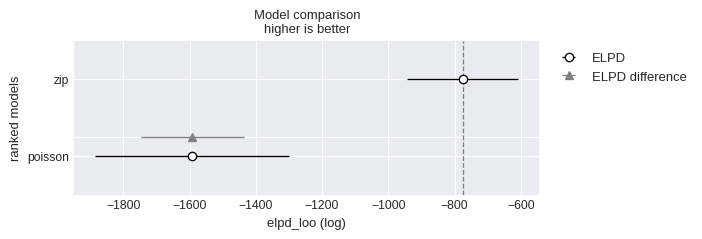

In [24]:
az.plot_compare(df_compare, insample_dev=False);

We can use the <code>interpret.plot_predictions</code> function to view the conditional effect of one variable on another in terms of prediction. For example, below, the number of fish caught depending on the number of persons per group. The <code>prob=0.95</code> argument specifies the size of highest density interval to provide.

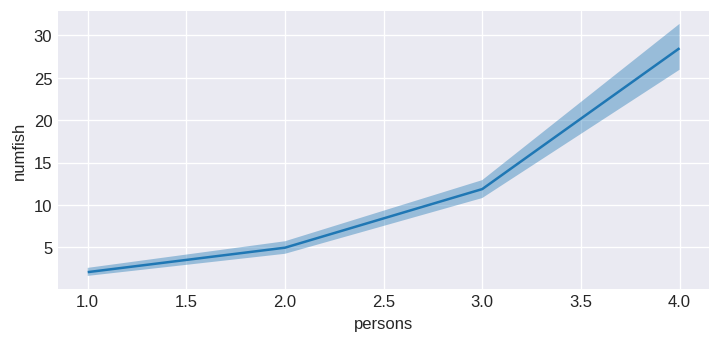

In [25]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(model_zip, idata_zip, conditional='persons', ax=ax, prob=0.95);

Similarly, we can compare number of fish caught to number of children in the group, and see that there is a decreasing relationship.

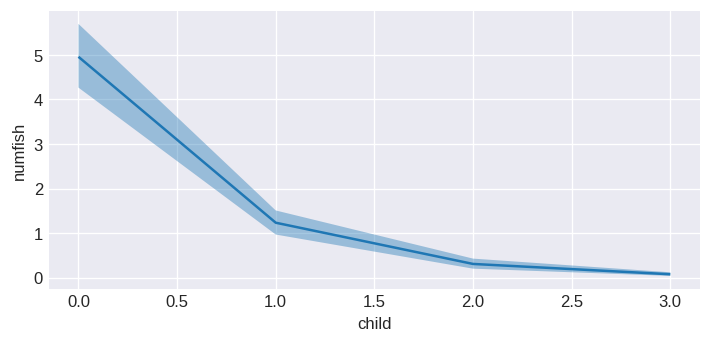

In [26]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(model_zip, idata_zip, conditional='child', ax=ax);

We can also use the <code>interpret.plot_comparisons</code> feature to view the conditional effect of one variable on another, while broken out by other variables. For example, below, we have number of persons on the x-axis, number of fish on the y-axis, and a breakout by number of children. As we would expect based on the prior charts, number of fish increases with the size of group, but does so in greatest fashion for the groups with less children.

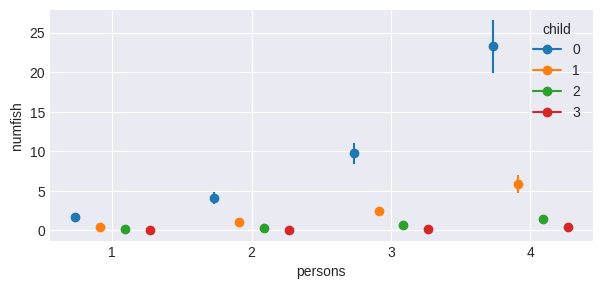

In [27]:
fig, ax = bmb.interpret.plot_comparisons(
    model=model_zip,
    idata=idata_zip,
    contrast={"livebait": [0, 1]},
    conditional=["persons", "child"],
)
fig.set_size_inches(7, 3)

Similarly, we can examine the contrast in number of fish caught between those with live bait and those without, in the context of another variable such as how many children were present.

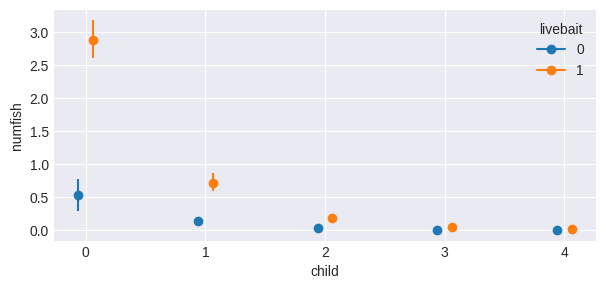

In [28]:
fig, ax = bmb.interpret.plot_comparisons(
    model=model_zip,
    idata=idata_zip,
    contrast={"persons": [1, 2]},
    conditional={"child": [0, 1, 2, 3, 4], "livebait": [0, 1]},
)
fig.set_size_inches(7, 3)

## Negative Binomial Regression

As mentioned above, a key assumption of the Poisson GLM is that the mean $\lambda$ is roughly equal to the variance. Variability is said to be overdispersed if the observed variance exceeds that expected by the model, and if a count variable is too overdispersed for the Poisson model, the Negative Binomial offers a suitable alternative. It too is suited to count data, but it does not constrain variance to be equal to the mean.

The PMF of the Negative Binomial distribution is:

$f(x|\mu, \alpha) = \binom{x + \alpha - 1}{x} \left( \frac{\alpha}{\mu + \alpha} \right)^{\alpha} \left( \frac{\mu}{\mu + \alpha} \right)^x$

$\alpha$ is a dispersion parameter, for which the Exponential provides a reasonable prior. For large $\alpha$, $Var(Y) \approx E(Y)$, and $Y$ behaves much like a Poisson random variable. For small $\alpha$, $Y$ is overdispersed compared to a Poisson variable.

As a side note, the Negative Binomial can be alternatively parameterized in terms of $n = \alpha$ and $p = \alpha / (\mu + \alpha)$, in which case it can be interpreted as the probability of x failures before the $n^{th}$ success.

The dataset corrsponds to a survey asking people how many murder victims they each know of. So again, we expect low counts, and a lot of zeros.

In [29]:
data = pd.read_csv('https://raw.githubusercontent.com/pw598/Articles/main/data/murders.csv')
data.head()

,observation,response
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


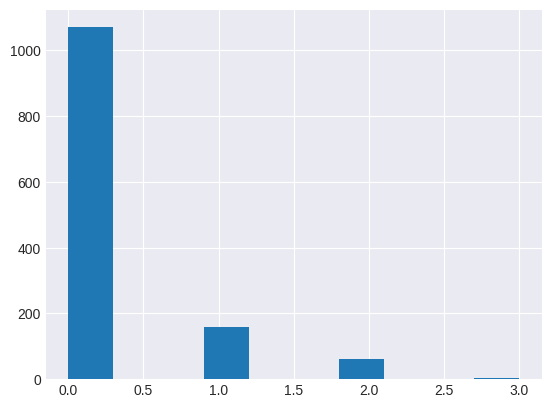

In [30]:
plt.hist(data['response']);

In [31]:
model_nb = bmb.Model("response ~ 0 + observation", data, family="negativebinomial")
idata_nb = model_nb.fit(idata_kwargs={"log_likelihood": True})

Output()

Output()

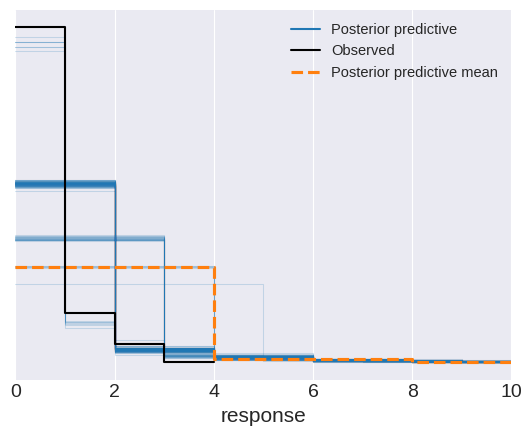

In [32]:
model_nb.predict(idata_nb, kind="response")
ax = az.plot_ppc(idata_nb, num_pp_samples=100)
ax.set_xlim(0, 10);

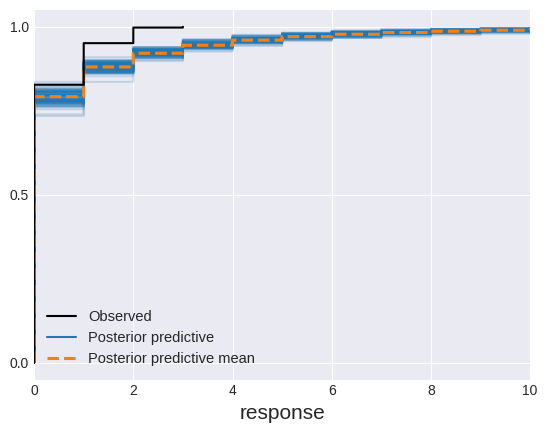

In [33]:
model_nb.predict(idata_nb, kind="response")
ax = az.plot_ppc(idata_nb, num_pp_samples=100, kind='cumulative')
ax.set_xlim(0, 10);

## Zero-Inflated Negative Binomial Regression

Like the zero-inflated Poisson, the zero-inflated Negative Binomial injects an additional parameter which allows the distribution to account for the additional variability. However, it's not a built-in family of <code>bambi</code>, so we use some additional syntax below.

In [34]:
likelihood = bmb.Likelihood("ZeroInflatedNegativeBinomial", params=["mu", "psi", "alpha"]) #, parent="mu")
links = {"mu": "log", "psi": "logit", "alpha": "log"}
zip_family = bmb.Family("zip", likelihood, links)

We can set priors as follows:

In [35]:
# this prior regularizes the results in a helpful direction, but involves no expert knowledge
priors = {"psi": bmb.Prior("Beta", alpha=1, beta=25), "alpha": bmb.Prior("Beta", alpha=1, beta=1)}

And then fit the model.

In [36]:
model_zinb = bmb.Model("response ~ 0 + observation", data, family=zip_family, priors=priors)
idata_zinb = model_zinb.fit(idata_kwargs={"log_likelihood": True})

Output()

Output()

ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


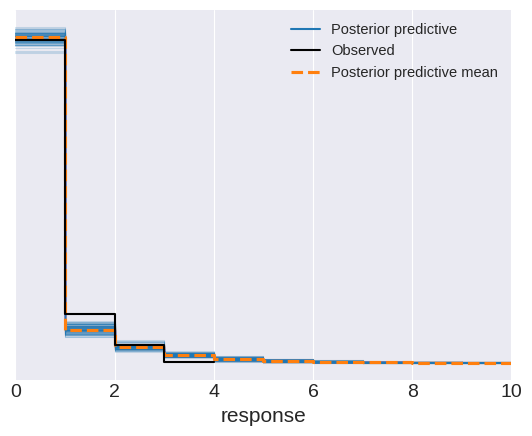

In [37]:
model_zinb.predict(idata_zinb, kind="response")
ax = az.plot_ppc(idata_zinb, num_pp_samples=100)
ax.set_xlim(0, 10);

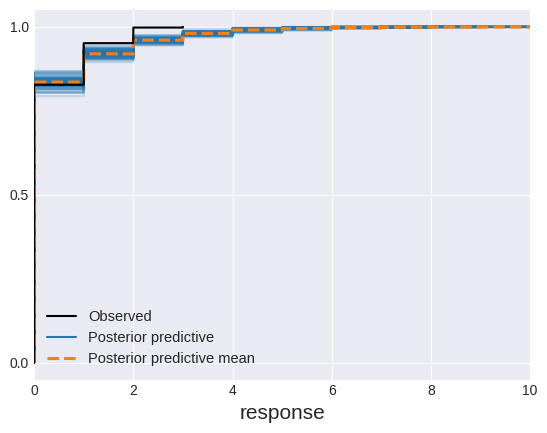

In [38]:
model_zinb.predict(idata_zinb, kind="response")
ax = az.plot_ppc(idata_zinb, num_pp_samples=100, kind="cumulative")
ax.set_xlim(0, 10);

#### Model Comparison

We can compare the plain Negative Binomial to the zero-inflated model as such:

In [39]:
models_dict = {
    "nb": idata_nb,
    "zinb": idata_zinb
}
df_compare = az.compare(models_dict)
df_compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
zinb,0,-800.447802,1.087303,0.000000,1.0,34.869531,0.000000,False,log
nb,1,-872.313650,1.363477,71.865848,0.0,34.494172,1.327796,False,log


We see that while the zero-inflated model fits better according the the <code>lpd_loo</code> score (as the visual suggested it would), the <code>p_loo</code> score is actually lower for the zero-inflated model because it has more parameters.

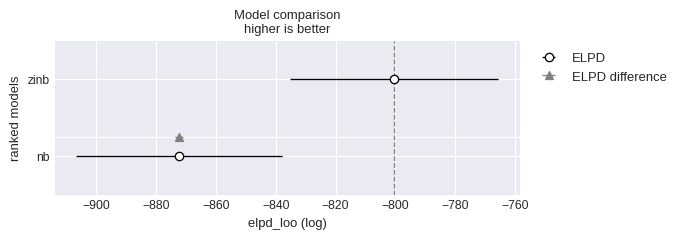

In [40]:
az.plot_compare(df_compare, insample_dev=False);

## Gamma Regression

What if we're measuring a process that produces positive real values that aren't counts? For parameters that live in this domain, we often consider the Exponential distribution as a prior, however this suffers from having only one parameter; once $\lambda$ is determined, so is both the shape and the rate. Alternatives include truncated distributions like the HalfNormal and HalfStudentT, as well as the Gamma distribution, which has shape parameter $\alpha$ and rate parameter $\beta$. The Exponential is actually a special case of the Gamma, where $\alpha=1$.

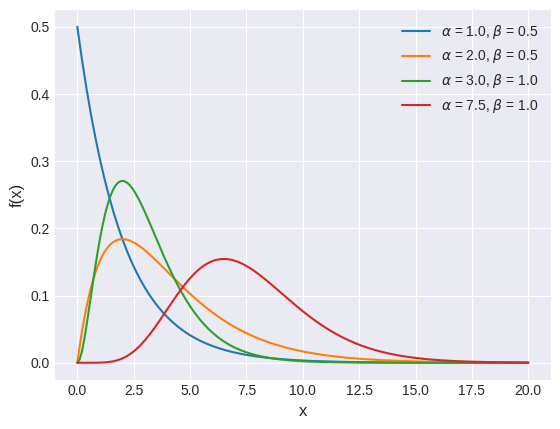

In [44]:
import scipy.stats as st
x = np.linspace(0, 20, 200)
alphas = [1., 2., 3., 7.5]
betas = [.5, .5, 1., 1.]
for a, b in zip(alphas, betas):
    pdf = st.gamma.pdf(x, a, scale=1.0/b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

For data, we'll look at the <code>carclaims</code> dataset which is built into <code>bambi</code>. The features are as follows:

In [42]:
data = bmb.load_data("carclaims")
data = data[data["claimcst0"] > 0]
data.head()

,veh_value,exposure,clm,numclaims,claimcst0,veh_body,veh_age,gender,area,agecat
14,1.66,0.484600,1,1,669.509999,SEDAN,3,M,B,6
16,1.51,0.993840,1,1,806.609999,SEDAN,3,F,F,4
17,0.76,0.539357,1,1,401.805451,HBACK,3,M,C,4
40,1.89,0.654346,1,2,1811.709997,STNWG,3,M,F,2
64,4.06,0.851472,1,1,5434.439987,STNWG,2,M,F,3


Claim amount is the target variable, and is distributed as follows:

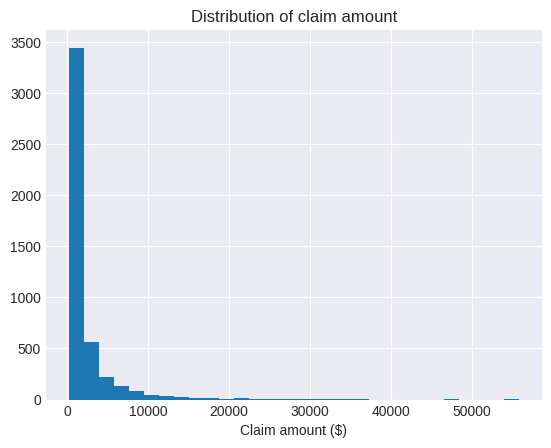

In [45]:
plt.hist(data["claimcst0"], bins=30)
plt.title("Distribution of claim amount")
plt.xlabel("Claim amount ($)");

#### Exponential Regression

For the sake of comparison, we'll first try fitting a simple Exponential model. Priors can be added using the same syntax as the other fit operations above.

In [77]:
model_exp = bmb.Model(
    "claimcst0 ~ agecat + gender + numclaims + veh_age + exposure",
    data,
    family="exponential",
    link="log",
    categorical="agecat" #,
    # priors=priors
)
idata_exp = model_exp.fit(tune=2000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Output()

Output()

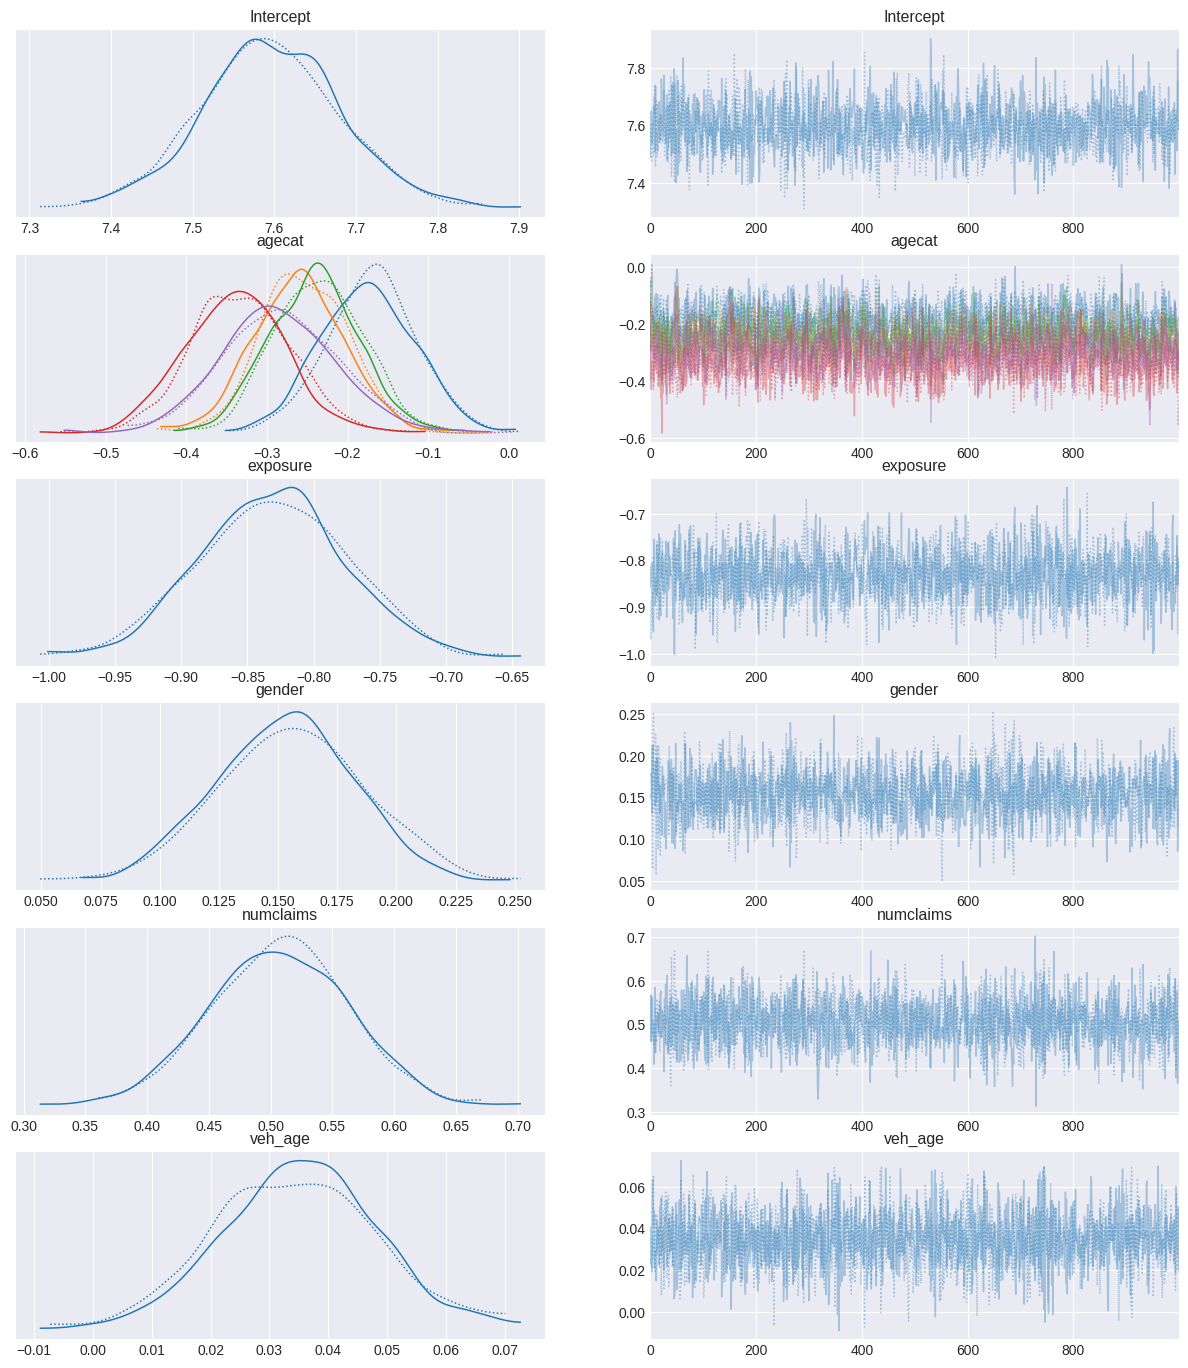

In [78]:
az.plot_trace(idata_exp, figsize=(15,17));

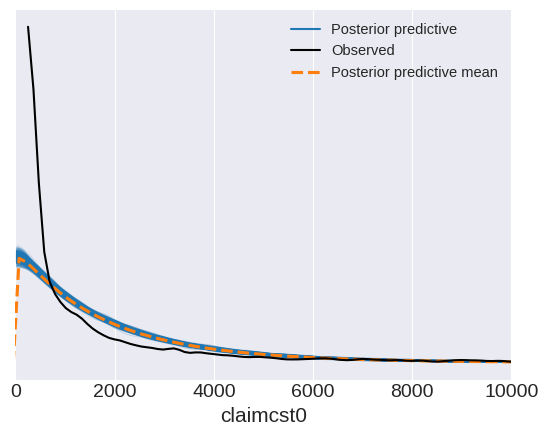

In [79]:
model_exp.predict(idata_exp, kind="response")
ax = az.plot_ppc(idata_exp, num_pp_samples=500);
ax.set_xlim(0, 10000);

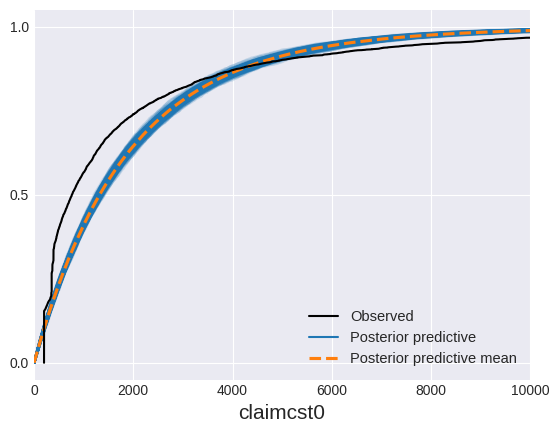

In [80]:
model_exp.predict(idata_exp, kind="response")
ax = az.plot_ppc(idata_exp, num_pp_samples=500, kind="cumulative");
ax.set_xlim(0, 10000);

There seems to be some room for improvement. Let's try a Gamma model.

In [81]:
# these priors on the Gamma target variable were chosen to regularize the result in an optimal direction
priors = {"alpha": 0.4, "beta": 1.5}

model_gamma = bmb.Model(
    "claimcst0 ~ agecat + gender + numclaims + veh_age + exposure",
    data,
    family="gamma",
    link="log",
    categorical="agecat",
    priors=priors
)
idata_gamma = model_gamma.fit(tune=2000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Output()

Output()

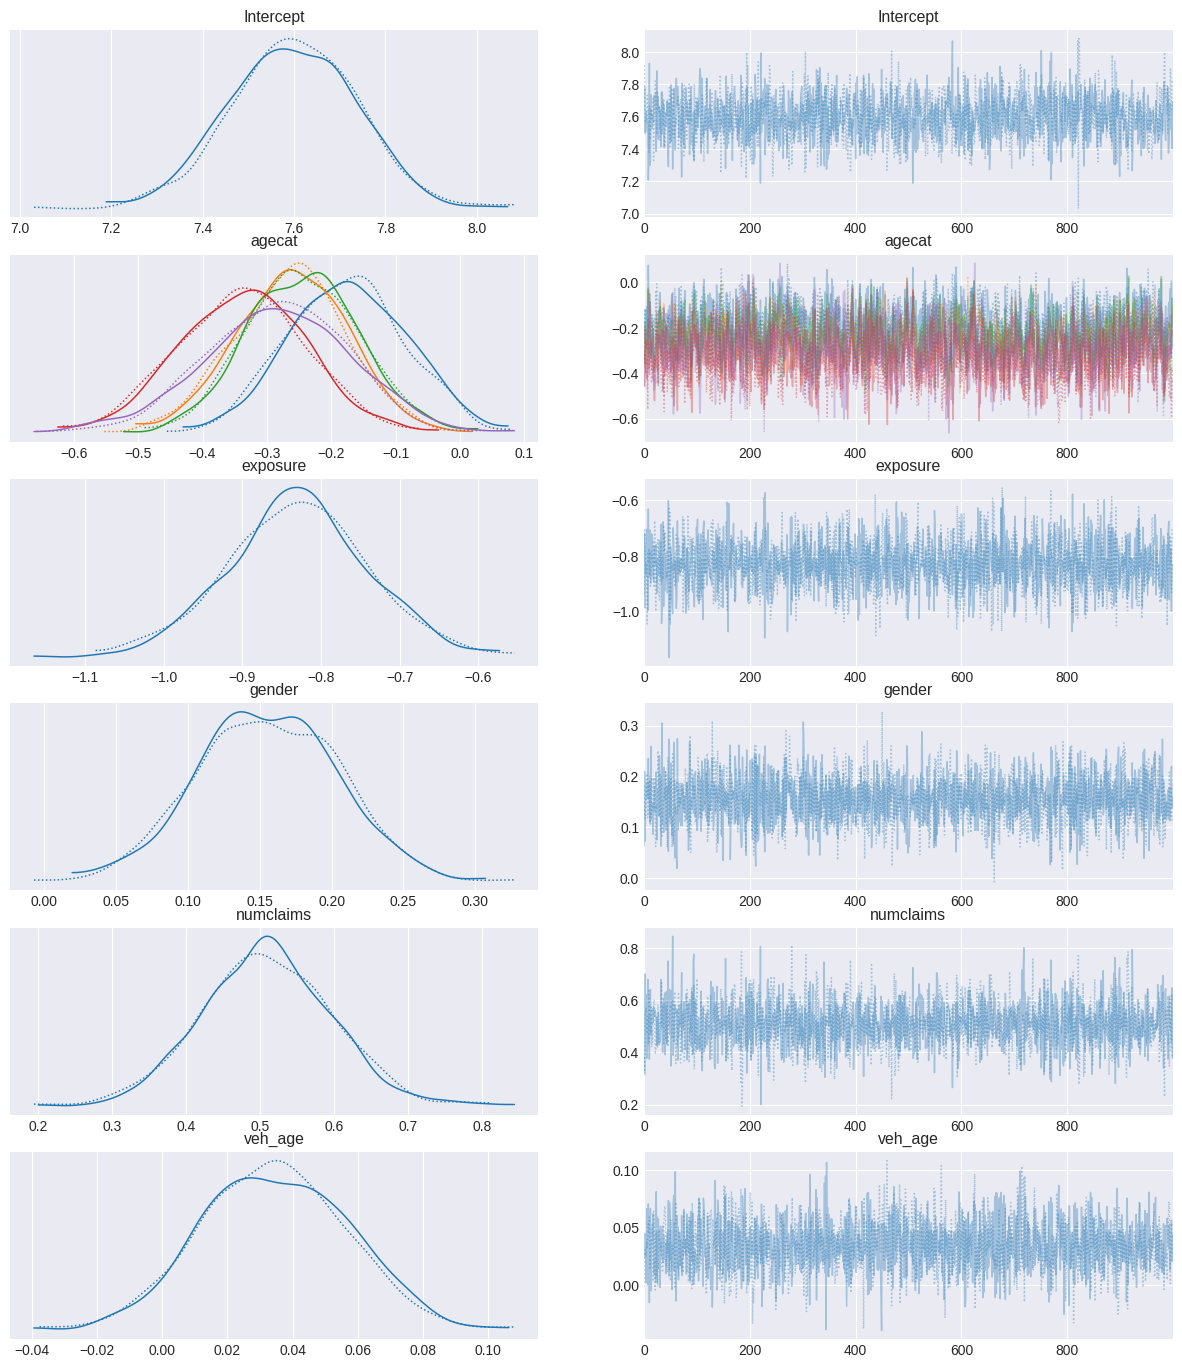

In [82]:
az.plot_trace(idata_gamma, figsize=(15,17));

And we can see that the results look much better.

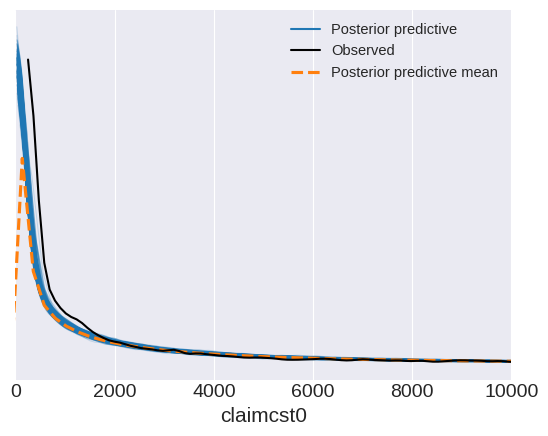

In [83]:
model_gamma.predict(idata_gamma, kind="response")
ax = az.plot_ppc(idata_gamma, num_pp_samples=500);
ax.set_xlim(0, 10000);

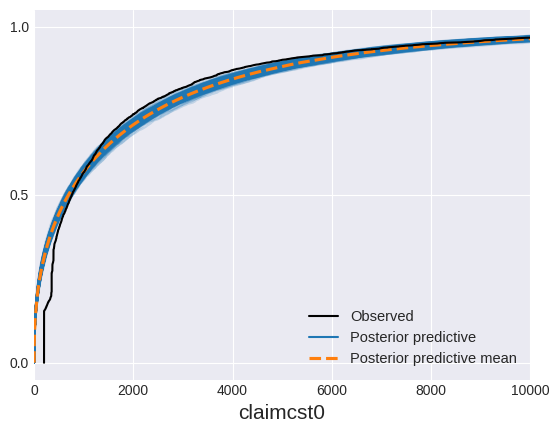

In [84]:
model_gamma.predict(idata_gamma, kind="response")
ax = az.plot_ppc(idata_gamma, num_pp_samples=500, kind='cumulative');
ax.set_xlim(0, 10000);

With that, we will conclude this article. The next one in the series is on Bayesian networks, and can be found <a href="">here</a>.

## References

- Davidson-Pilon, C. Bayesian Methods for Hackers. https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/#contents

- Martin, O. (2024). Bayesian Analysis with Python (3rd ed.). Packt. https://www.packtpub.com/en-ca/product/bayesian-analysis-with-python-9781805127161

- Johnson, A. A., Ott, M. Q., & Dogucu, M. (2012). Bayes Rules! CRC Press. https://www.bayesrulesbook.com/

- (n.d.). Bambi User Docs. https://bambinos.github.io/bambi/

- (n.d.). Bambi User Docs: Examples. https://bambinos.github.io/bambi/notebooks/

- (n.d.). PyMC User Docs. https://www.pymc.io/projects/examples/en/latest/gallery.html